# 2D lattice

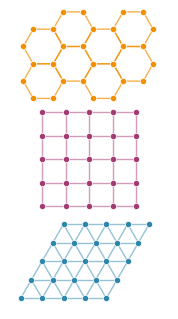

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import matplotlib.gridspec as gridspec


def plot_hexagonal_lattice(ax, color):
    """绘制六角格子（蜂巢格子）"""
    ax.set_aspect('equal')
    
    # 生成六角格子
    offset = np.sqrt(3) * HEX_RADIUS
    Vectors = [(1, np.sqrt(3)), (1, -np.sqrt(3)), (2, 0),
               (-1, np.sqrt(3)), (-1, -np.sqrt(3)), (-2, 0)]
    
    for i in range(HEX_SIZE):
        for j in range(HEX_SIZE):
            # A子晶格
            x_a = 3 * HEX_RADIUS * i
            y_a = offset * j
            hex_a = RegularPolygon((x_a, y_a), numVertices=6, radius=HEX_RADIUS, 
                                  orientation=np.pi/6, facecolor='none', 
                                  edgecolor=color, linewidth=LINE_WIDTH, alpha=LINE_ALPHA+0.2)
            ax.add_patch(hex_a)
            for vec1 in Vectors:
                x1 = x_a + vec1[0] * HEX_RADIUS*0.5
                y1 = y_a + vec1[1] * HEX_RADIUS*0.5
                ax.scatter(x1, y1, color=color, s=POINT_SIZE, zorder=3,
                          edgecolors=POINT_EDGE_COLOR, linewidth=POINT_EDGE_WIDTH)
            
            # B子晶格
            x_b = x_a + 1.5 * HEX_RADIUS
            y_b = y_a + offset/2
            hex_b = RegularPolygon((x_b, y_b), numVertices=6, radius=HEX_RADIUS,
                                  orientation=np.pi/6, facecolor='none',
                                  edgecolor=color, linewidth=LINE_WIDTH, alpha=LINE_ALPHA+0.2)
            ax.add_patch(hex_b)
            for vec1 in Vectors:
                x1 = x_b + vec1[0] * HEX_RADIUS*0.5
                y1 = y_b + vec1[1] * HEX_RADIUS*0.5
                ax.scatter(x1, y1, color=color, s=POINT_SIZE, zorder=3,
                          edgecolors=POINT_EDGE_COLOR, linewidth=POINT_EDGE_WIDTH)
    
    ax.set_xlim(-HEX_RADIUS-0.2, 3*HEX_RADIUS*(HEX_SIZE-1) + 2*HEX_RADIUS + 0.5)
    ax.set_ylim(-HEX_RADIUS-0.2, offset*(HEX_SIZE-1) + offset/2 + HEX_RADIUS - 0.002)
    ax.grid(False)
    ax.set_axis_off()
    
    return ax

def plot_square_lattice(ax, color, scafac=1.2):
    """绘制正方格子"""
    ax.set_aspect('equal')
    
    # 生成正方格子
    x, y = np.meshgrid(np.arange(GRID_SIZE)*scafac, np.arange(GRID_SIZE)*scafac)
    ax.scatter(x.flatten(), y.flatten(), color=color, s=POINT_SIZE, zorder=3, 
               edgecolors=POINT_EDGE_COLOR, linewidth=POINT_EDGE_WIDTH)
    
    # 连接线
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            x0 = i * scafac; x1 = (i+1) * scafac
            y0 = j * scafac; y1 = (j+1) * scafac 
            if j < GRID_SIZE-1:
                ax.plot([x0, x0], [y0, y1], color=color, alpha=LINE_ALPHA, linewidth=LINE_WIDTH)
            if i < GRID_SIZE-1:
                ax.plot([x0, x1], [y0, y0], color=color, alpha=LINE_ALPHA, linewidth=LINE_WIDTH)
    
    ax.set_xlim(-0.15, GRID_SIZE-0.05)
    ax.set_ylim(-0.15, GRID_SIZE-0.05)
    ax.set_axis_off()
    
    return ax

def plot_triangular_lattice(ax, color, stafac=1.0):
    """绘制三角格子"""
    ax.set_aspect('equal')
    
    # 生成三角格子
    points = []
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            x_pos = i + j*0.5
            y_pos = j * np.sqrt(3)*0.5
            points.append((x_pos, y_pos))
            if i > 0:
                ax.plot([x_pos, x_pos-1], [y_pos, y_pos], color=color, 
                       alpha=LINE_ALPHA, linewidth=LINE_WIDTH)
            if j > 0:
                ax.plot([x_pos, x_pos-0.5], [y_pos, y_pos-np.sqrt(3)/2], 
                       color=color, alpha=LINE_ALPHA, linewidth=LINE_WIDTH)
                if i < GRID_SIZE-1:
                    ax.plot([x_pos, x_pos+0.5], [y_pos, y_pos-np.sqrt(3)/2], 
                           color=color, alpha=LINE_ALPHA, linewidth=LINE_WIDTH)
    
    points = np.array(points)
    ax.scatter(points[:, 0], points[:, 1], color=color, s=POINT_SIZE, zorder=3,
               edgecolors=POINT_EDGE_COLOR, linewidth=POINT_EDGE_WIDTH)
    
    ax.set_xlim(-0.5, GRID_SIZE+1.9)
    ax.set_ylim(-0.5, (GRID_SIZE-1)*np.sqrt(3)/2 + 0.7)
    ax.grid(False)
    ax.set_axis_off()
    
    return ax

# 设置Nature Communication风格
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
})

# ==================== 全局参数设置 ====================
# 颜色设置
#COLORS = ['#2E86AB', '#A23B72', '#F18F01']  # Nature风格的颜色
COLORS = ['#F18F01','#A23B72',  '#2E86AB' ]  # Nature风格的颜色
BG_COLOR = '#F8F9FA'

# 点和线参数
POINT_SIZE = 20
POINT_EDGE_WIDTH = 0.5
POINT_EDGE_COLOR = 'white'
LINE_WIDTH = 1
LINE_ALPHA = 0.5

# 格子尺寸
GRID_SIZE = 5
HEX_SIZE = 2  # 六角格子尺寸
HEX_RADIUS = 0.5  # 六角格子半径
fig, axes = plt.subplots(3, 1, figsize=(2, 3))

ax = axes[0]
plot_hexagonal_lattice(ax, COLORS[0])

ax = axes[1]
plot_square_lattice(ax, COLORS[1])

ax = axes[2]
plot_triangular_lattice(ax, COLORS[2])
plt.tight_layout(pad=0.01, h_pad=0.01, w_pad=0.01)
plt.savefig("2DTopology.svg")
plt.show()



100%|██████████| 100/100 [00:00<00:00, 3139.75it/s]
101it [00:04, 23.36it/s]
100%|██████████| 100/100 [00:00<00:00, 2351.77it/s]
101it [00:04, 21.88it/s]
100%|██████████| 100/100 [00:00<00:00, 2396.72it/s]
101it [00:04, 20.69it/s]


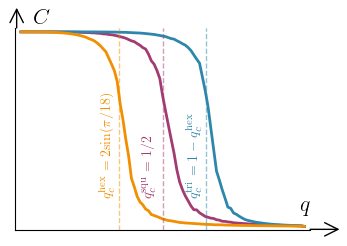

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# 设置Nature风格
plt.rcParams.update({
    'font.size': 24,
    'font.family': 'sans-serif',
    'text.usetex': True,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

#    'font.sans-serif': ['Arial'],
# ==================== 全局参数 ====================
L = 32  # 系统尺寸
MC_STEPS = 100  # 每个p值的蒙特卡洛步数
P_POINTS = 101  # p值的点数（从0到1）
#COLORS = ['#2E86AB', '#A23B72', '#F18F01']  
COLORS = ['#A23B72','#2E86AB','#F18F01' ]  # 正方、三角、六角晶格的颜色

# ==================== 晶格构建函数 ====================

def build_square_lattice(L):
    """构建正方晶格的边列表"""
    N = L * L
    edges = []
    
    # 生成所有节点编号
    nodes = np.arange(N).reshape(L, L)
    
    # 水平边
    for i in range(L):
        for j in range(L):
            # 向右的边
            edges.append((nodes[i, j], nodes[i, (j+1)%L]))
            # 向下的边
            edges.append((nodes[i, j], nodes[(i+1)%L, j]))
    
    return np.array(edges, dtype=int)

def build_triangular_lattice(L):
    """构建三角晶格的边列表"""
    N = L * L
    edges = []
    
    # 生成所有节点编号
    nodes = np.arange(N).reshape(L, L)
    
    for i in range(L):
        for j in range(L):
            # 向右的边
            edges.append((nodes[i, j], nodes[i, (j+1)%L]))
            # 向下的边
            edges.append((nodes[i, j], nodes[(i+1)%L, j]))
            # 向右下的对角线边
            edges.append((nodes[i, j], nodes[(i+1)%L, (j+1)%L]))
    
    return np.array(edges, dtype=int)

def build_hexagonal_lattice(L):
    """构建六角（蜂巢）晶格的边列表"""
    # 六角晶格有2个子晶格
    N = 2 * L * L
    edges = []
    
    # 生成所有节点编号
    nodes = np.arange(N).reshape(2, L, L)
    
    for i in range(L):
        for j in range(L):
            # A子晶格节点 (0,i,j)
            a_node = nodes[0, i, j]
            
            # 连接到三个相邻的B子晶格节点
            # 右连接
            b1 = nodes[1, i, j]
            edges.append((a_node, b1))
            
            # 左上连接
            b2 = nodes[1, (i-1+L)%L, j]
            edges.append((a_node, b2))
            
            # 左下连接
            b3 = nodes[1, i, (j-1+L)%L]
            edges.append((a_node, b3))
    
    return np.array(edges, dtype=int)

# ==================== 渗流模拟函数 ====================

def simulate_percolation(edges, p, mc_steps=MC_STEPS):
    """模拟渗流过程，返回最大集团大小的平均值"""
    M = len(edges)  # 边的总数
    max_cluster_sizes = []
    
    for _ in tqdm( range(mc_steps) ):
        # 随机选择占据的边
        occupied = np.random.rand(M) < p
        occupied_edges = edges[occupied]
        
        if len(occupied_edges) == 0:
            max_cluster_sizes.append(0)
            continue
        
        # 构建邻接矩阵的CSR格式
        n_vertices = np.max(edges) + 1
        row = np.concatenate([occupied_edges[:, 0], occupied_edges[:, 1]])
        col = np.concatenate([occupied_edges[:, 1], occupied_edges[:, 0]])
        data = np.ones(len(row), dtype=int)
        
        # 使用稀疏矩阵计算连通分量
        adj_matrix = csr_matrix((data, (row, col)), shape=(n_vertices, n_vertices))
        n_components, labels = connected_components(adj_matrix, directed=False, return_labels=True)
        
        # 计算每个集团的大小
        if n_components > 0:
            cluster_sizes = np.bincount(labels)
            max_cluster_sizes.append(np.max(cluster_sizes) / n_vertices)  # 归一化
        else:
            max_cluster_sizes.append(0)
    
    return np.mean(max_cluster_sizes), np.std(max_cluster_sizes) / np.sqrt(mc_steps)

# ==================== 主模拟程序 ====================

def main():
    # 生成p值数组
    p_values = np.linspace(0, 1, P_POINTS)
    
    # 存储结果的字典
    results = {
        'square': {'mean': [], 'std': []},
        'triangular': {'mean': [], 'std': []},
        'hexagonal': {'mean': [], 'std': []}
    }
    
    edges_square = build_square_lattice(L)
    for i, p in tqdm( enumerate(p_values) ):
        mean, std = simulate_percolation(edges_square, p)
        results['square']['mean'].append(mean)
        results['square']['std'].append(std)
    
    edges_tri = build_triangular_lattice(L)
    for i, p in tqdm( enumerate(p_values) ):
        mean, std = simulate_percolation(edges_tri, p)
        results['triangular']['mean'].append(mean)
        results['triangular']['std'].append(std)
    
    edges_hex = build_hexagonal_lattice(L)
    for i, p in tqdm( enumerate(p_values) ):
        mean, std = simulate_percolation(edges_hex, p)
        results['hexagonal']['mean'].append(mean)
        results['hexagonal']['std'].append(std)
    
    # ==================== 绘制结果 ====================
    fig, ax = plt.subplots(figsize=(4, 3))
    
    ax.plot(1.0-p_values, results['square']['mean'], color=COLORS[0], linewidth=2, label='Square lattice')
    ax.plot(1.0-p_values, results['triangular']['mean'], color=COLORS[1], linewidth=2, label='Triangular lattice')
    ax.plot(1.0-p_values, results['hexagonal']['mean'], color=COLORS[2], linewidth=2, label='Hexagonal lattice')
   
    ax.set_xlabel('$q$',fontsize=16, loc='right', labelpad=-25)
    ax.set_ylabel('$C$',fontsize=16, loc='top'  , labelpad=-25, rotation=0)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels("")
    ax.set_yticklabels("")
#    ax.set_axis_off() 
    ax.spines['top'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    # 添加箭头
    # x轴箭头
    ax.annotate('', xy=(1.1, -0.015), xycoords=('axes fraction', 'data'),
                xytext=(1.0, -0.015), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=1, shrinkA=0, shrinkB=0))

    # y轴箭头
    ax.annotate('', xy=(-0.015, 1.1), xycoords=('data', 'axes fraction'),
                xytext=(-0.015, 1.0), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=1, shrinkA=0, shrinkB=0))

    # 添加理论渗流阈值线
    # 正方晶格：p_c ≈ 0.5
    # 三角晶格：p_c ≈ 0.3473
    # 六角晶格：p_c ≈ 0.6527
    ax.axvline(x=1.0-0.5   , color=COLORS[0], linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=1.0-0.3473, color=COLORS[1], linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=1.0-0.6527, color=COLORS[2], linestyle='--', alpha=0.5, linewidth=1)
    
    # 添加理论值标签
    ax.text(0.45,0.16, r'$q_c^{\mathrm{squ}} = 1/2$',                  color=COLORS[0], fontsize=10, ha='center',rotation=90, transform=ax.transData)
    ax.text(0.61,0.16, r'$q_c^{\mathrm{tri}} = 1-q_c^{\mathrm{hex}}$' ,color=COLORS[1], fontsize=10, ha='center',rotation=90, transform=ax.transData)
    ax.text(0.3, 0.16, r'$q_c^{\mathrm{hex}} = 2\mathrm{sin}(\pi/18)$',color=COLORS[2], fontsize=10, ha='center',rotation=90, transform=ax.transData)
    
    plt.tight_layout()
    plt.show()
    
    

if __name__ == "__main__":
    main()

Data file 2DBondL1024.dat found, loading data for plotting...
Loaded 101 data points from 2DBondL1024.dat


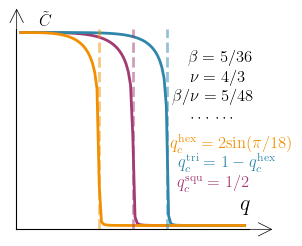

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import warnings
from tqdm import tqdm
import os
warnings.filterwarnings('ignore')

# Set Nature style
plt.rcParams.update({
    'font.size': 24,
    'font.family': 'sans-serif',
    'text.usetex': True,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

# ==================== Global Parameters ====================
L = 1024  # System size
MC_STEPS = 100  # Monte Carlo steps for each p
P_POINTS = 101  # Number of p points (0 to 1)
COLORS = ['#A23B72', '#2E86AB', '#F18F01']  # Square, Triangular, Hexagonal colors
DATA_FILE = f'2DBondL{L}.dat'  # Data storage file

# ==================== Lattice Construction Functions ====================

def build_square_lattice(L):
    """Build square lattice edge list"""
    N = L * L
    edges = []
    
    # Generate all node indices
    nodes = np.arange(N).reshape(L, L)
    
    # Horizontal edges
    for i in range(L):
        for j in range(L):
            # Right edge
            edges.append((nodes[i, j], nodes[i, (j+1)%L]))
            # Down edge
            edges.append((nodes[i, j], nodes[(i+1)%L, j]))
    
    return np.array(edges, dtype=int)

def build_triangular_lattice(L):
    """Build triangular lattice edge list"""
    N = L * L
    edges = []
    
    # Generate all node indices
    nodes = np.arange(N).reshape(L, L)
    
    for i in range(L):
        for j in range(L):
            # Right edge
            edges.append((nodes[i, j], nodes[i, (j+1)%L]))
            # Down edge
            edges.append((nodes[i, j], nodes[(i+1)%L, j]))
            # Diagonal edge (down-right)
            edges.append((nodes[i, j], nodes[(i+1)%L, (j+1)%L]))
    
    return np.array(edges, dtype=int)

def build_hexagonal_lattice(L):
    """Build hexagonal (honeycomb) lattice edge list"""
    # Hexagonal lattice has 2 sublattices
    N = 2 * L * L
    edges = []
    
    # Generate all node indices
    nodes = np.arange(N).reshape(2, L, L)
    
    for i in range(L):
        for j in range(L):
            # A sublattice node (0,i,j)
            a_node = nodes[0, i, j]
            
            # Connect to three neighboring B sublattice nodes
            # Right connection
            b1 = nodes[1, i, j]
            edges.append((a_node, b1))
            
            # Upper-left connection
            b2 = nodes[1, (i-1+L)%L, j]
            edges.append((a_node, b2))
            
            # Lower-left connection
            b3 = nodes[1, i, (j-1+L)%L]
            edges.append((a_node, b3))
    
    return np.array(edges, dtype=int)

# ==================== Percolation Simulation Function ====================

def simulate_percolation(edges, p, mc_steps=MC_STEPS):
    """Simulate percolation process, return average max cluster size"""
    M = len(edges)  # Total number of edges
    max_cluster_sizes = []
    
    for _ in range(mc_steps):
        # Randomly select occupied edges
        occupied = np.random.rand(M) < p
        occupied_edges = edges[occupied]
        
        if len(occupied_edges) == 0:
            max_cluster_sizes.append(0)
            continue
        
        # Build CSR format adjacency matrix
        n_vertices = np.max(edges) + 1
        row = np.concatenate([occupied_edges[:, 0], occupied_edges[:, 1]])
        col = np.concatenate([occupied_edges[:, 1], occupied_edges[:, 0]])
        data = np.ones(len(row), dtype=int)
        
        # Calculate connected components using sparse matrix
        adj_matrix = csr_matrix((data, (row, col)), shape=(n_vertices, n_vertices))
        n_components, labels = connected_components(adj_matrix, directed=False, return_labels=True)
        
        # Calculate cluster sizes
        if n_components > 0:
            cluster_sizes = np.bincount(labels)
            max_cluster_sizes.append(np.max(cluster_sizes) / n_vertices)  # Normalized
        else:
            max_cluster_sizes.append(0)
    
    return np.mean(max_cluster_sizes), np.std(max_cluster_sizes) / np.sqrt(mc_steps)

# ==================== Data Storage and Loading Functions ====================

def save_results_to_file(p_values, results):
    """Save simulation results to file"""
    with open(DATA_FILE, 'w') as f:
        # Write header
        f.write("# 2D bond percolation simulation results\n")
        f.write(f"# L={L}, MC_STEPS={MC_STEPS}, P_POINTS={P_POINTS}\n")
        f.write("# p_values, square_mean, square_std, triangular_mean, triangular_std, hexagonal_mean, hexagonal_std\n")
        
        # Write data
        for i, p in enumerate(p_values):
            f.write(f"{p:.6f} ")
            f.write(f"{results['square']['mean'][i]:.6f} {results['square']['std'][i]:.6f} ")
            f.write(f"{results['triangular']['mean'][i]:.6f} {results['triangular']['std'][i]:.6f} ")
            f.write(f"{results['hexagonal']['mean'][i]:.6f} {results['hexagonal']['std'][i]:.6f}\n")
    
    print(f"Results saved to {DATA_FILE}")

def load_results_from_file():
    """Load simulation results from file"""
    if not os.path.exists(DATA_FILE):
        print(f"Data file {DATA_FILE} does not exist, please run simulation first")
        return None, None
    
    p_values = []
    results = {
        'square': {'mean': [], 'std': []},
        'triangular': {'mean': [], 'std': []},
        'hexagonal': {'mean': [], 'std': []}
    }
    
    with open(DATA_FILE, 'r') as f:
        for line in f:
            # Skip comment lines
            if line.startswith('#'):
                continue
            
            # Parse data line
            data = line.strip().split()
            if len(data) == 7:
                p_values.append(float(data[0]))
                results['square']['mean'].append(float(data[1]))
                results['square']['std'].append(float(data[2]))
                results['triangular']['mean'].append(float(data[3]))
                results['triangular']['std'].append(float(data[4]))
                results['hexagonal']['mean'].append(float(data[5]))
                results['hexagonal']['std'].append(float(data[6]))
    
    p_values = np.array(p_values)
    print(f"Loaded {len(p_values)} data points from {DATA_FILE}")
    return p_values, results

# ==================== Main Simulation Function ====================

def run_simulation():
    """Run simulation and save results to file"""
    # Generate p values array
    p_values = np.linspace(0, 1, P_POINTS)
    
    # Dictionary to store results
    results = {
        'square': {'mean': [], 'std': []},
        'triangular': {'mean': [], 'std': []},
        'hexagonal': {'mean': [], 'std': []}
    }
    
    print("Starting square lattice simulation...")
    edges_square = build_square_lattice(L)
    for i, p in enumerate(tqdm(p_values, desc="Square lattice")):
        mean, std = simulate_percolation(edges_square, p)
        results['square']['mean'].append(mean)
        results['square']['std'].append(std)
    
    print("Starting triangular lattice simulation...")
    edges_tri = build_triangular_lattice(L)
    for i, p in enumerate(tqdm(p_values, desc="Triangular lattice")):
        mean, std = simulate_percolation(edges_tri, p)
        results['triangular']['mean'].append(mean)
        results['triangular']['std'].append(std)
    
    print("Starting hexagonal lattice simulation...")
    edges_hex = build_hexagonal_lattice(L)
    for i, p in enumerate(tqdm(p_values, desc="Hexagonal lattice")):
        mean, std = simulate_percolation(edges_hex, p)
        results['hexagonal']['mean'].append(mean)
        results['hexagonal']['std'].append(std)
    
    # Save results to file
    save_results_to_file(p_values, results)
    
    return p_values, results

def plot_results(p_values, results):
    """Plot the results"""
    fig, ax = plt.subplots(figsize=(3.5, 3))
    
    # Plot curves
    ax.plot(1.0-p_values, results['square']['mean'], color=COLORS[0], linewidth=2, label='Square lattice')
    ax.plot(1.0-p_values, results['triangular']['mean'], color=COLORS[1], linewidth=2, label='Triangular lattice')
    ax.plot(1.0-p_values, results['hexagonal']['mean'], color=COLORS[2], linewidth=2, label='Hexagonal lattice')
   
    # Set axis labels
    ax.set_xlabel('$q$',          fontsize=16, loc='right', labelpad=-25)
    ax.set_ylabel('$\\tilde{C}$', fontsize=12, loc='top',   labelpad=-25, rotation=0)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels("")
    ax.set_yticklabels("")
    
    # Hide top and right spines
    ax.spines['top'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    
    # Add arrows
    # x-axis arrow
    ax.annotate('', xy=(1.1, -0.02), xycoords=('axes fraction', 'data'),
                xytext=(1.0, -0.02), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=0.5, shrinkA=0, shrinkB=0))

    # y-axis arrow
    ax.annotate('', xy=(-0.019, 1.1), xycoords=('data', 'axes fraction'),
                xytext=(-0.019, 1.0), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', color='black', 
                lw=0.5, shrinkA=0, shrinkB=0))

    # Add theoretical percolation threshold lines
    ax.axvline(x=1.0-0.5,    color=COLORS[0], linestyle='--', alpha=0.5, linewidth=2)
    ax.axvline(x=1.0-0.3473, color=COLORS[1], linestyle='--', alpha=0.5, linewidth=2)
    ax.axvline(x=1.0-0.6527, color=COLORS[2], linestyle='--', alpha=0.5, linewidth=2)
    
    # Add theoretical value labels
#    ax.text(0.45, 0.16, r'$q_c^{\mathrm{squ}} = 1/2$',                   color=COLORS[0], fontsize=10, ha='center', rotation=90, transform=ax.transData)
#    ax.text(0.61, 0.16, r'$q_c^{\mathrm{tri}} = 1-q_c^{\mathrm{hex}}$',  color=COLORS[1], fontsize=10, ha='center', rotation=90, transform=ax.transData)
#    ax.text(0.30, 0.16, r'$q_c^{\mathrm{hex}} = 2\mathrm{sin}(\pi/18)$', color=COLORS[2], fontsize=10, ha='center', rotation=90, transform=ax.transData)
    ft1 = 12
    ax.text(0.82 + 0.04, 0.20, '$q_c^{\mathrm{squ}} = 1/2$',                   color=COLORS[0], fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.88 + 0.04, 0.30, '$q_c^{\mathrm{tri}} = 1-q_c^{\mathrm{hex}}$',  color=COLORS[1], fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.90 + 0.04, 0.40, '$q_c^{\mathrm{hex}} = 2\mathrm{sin}(\pi/18)$', color=COLORS[2], fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.85 + 0.04, 0.85, '$\\beta = 5/36$',      color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.84 + 0.04, 0.75, '$\\nu = 4/3$',         color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.82 + 0.04, 0.65, '$\\beta/\\nu = 5/48$', color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)
    ax.text(0.82 + 0.04, 0.55, '$\\cdots$ $\\cdots$', color="black", fontsize=ft1, ha='center', rotation=0, transform=ax.transData)

    plt.tight_layout()
    plt.savefig("2DAttack.svg")
    plt.show()

# ==================== Main Function ====================

def main():
    """Main function: plot directly if data file exists, otherwise run simulation first"""
    if os.path.exists(DATA_FILE):
        print(f"Data file {DATA_FILE} found, loading data for plotting...")
        p_values, results = load_results_from_file()
        if p_values is not None:
            plot_results(p_values, results)
    else:
        print(f"Data file {DATA_FILE} not found, starting simulation...")
        p_values, results = run_simulation()
        plot_results(p_values, results)

if __name__ == "__main__":
    main()